In [12]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "analysis" / "src").exists() and (candidate / "data").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(f"Could not locate project root from {Path.cwd().resolve()}")
DROPBOX_ROOT = Path("/Users/satoshi/Library/CloudStorage/Dropbox/HSA_NKPC_MCMC")
sys.path.append(str(PROJECT_ROOT / "analysis" / "src"))
sys.path.append(str(PROJECT_ROOT / "analysis" / "gibbs"))

DATA_DIR = PROJECT_ROOT / "data"
IDATA_ROOT = DROPBOX_ROOT / "results" / "idata"
FIG_ROOT = PROJECT_ROOT / "results" / "fig"
TEX_ROOT_DIR = PROJECT_ROOT / "results" / "tex"

# Change DROPBOX_ROOT above if your Dropbox location differs.
# This notebook loads saved idata from Dropbox for comparison.

from func_data_build import build_dataset

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

data = build_dataset(DATA_DIR)
data["DATE"] = pd.to_datetime(data.index)

inflation_specs = {
    "ppi": {
        "pi": "pi_ppi",
        "pi_prev": "pi_ppi_prev",
        "pi_expect": "Epi_spf_gdp",
    },
    "cpi": {
        "pi": "pi_cpi",
        "pi_prev": "pi_cpi_prev",
        "pi_expect": "Epi_spf_cpi",
    },
}


/opt/homebrew/Caskroom/miniforge/base/envs/bayes-env/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [13]:
INFLATION_LABELS = {
    "S1": "PPI",
    "S2": "CPI",
}

GAP_LABELS = {
    "U": ("unemployment gap", "unemp_gap"),
    "Y": ("output gap", "output_gap_BN"),
}

N_LABELS = {
    "G": ("Gustavo", "N_Gustavo"),
    "T": ("TNIC", "N_TNIC"),
}


def make_model_sample(data, spec, inflation_specs, include_N=True):
    infl = inflation_specs[spec["inflation"]]
    gap = spec["gap"]

    required_cols = [
        infl["pi"],
        infl["pi_prev"],
        infl["pi_expect"],
        gap,
        f"{gap}_prev",
    ]

    if include_N:
        required_cols.append(spec["N"])

    sample = (
        data[required_cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )
    return sample


def parse_base_model_code(base_model: str) -> dict:
    set_code, gap_code, n_code = base_model.split("_")
    inflation_key = "ppi" if set_code == "S1" else "cpi"
    inflation_label = INFLATION_LABELS[set_code]
    gap_label, gap_col = GAP_LABELS[gap_code]
    n_label, n_col = N_LABELS[n_code]

    spec = {
        "model_id": base_model,
        "set": 1 if set_code == "S1" else 2,
        "inflation": inflation_key,
        "gap": gap_col,
        "N": n_col,
    }
    sample = make_model_sample(data, spec, inflation_specs, include_N=True)

    start = pd.Period(sample.index.min(), freq="Q")
    end = pd.Period(sample.index.max(), freq="Q")

    return {
        "base_model": base_model,
        "set_code": set_code,
        "gap_code": gap_code,
        "n_code": n_code,
        "inflation_label": inflation_label,
        "gap_label": gap_label,
        "n_label": n_label,
        "sample_start": str(start),
        "sample_end": str(end),
        "sample_period": f"{start} to {end}",
        "sample_size": int(len(sample)),
        "model_description": f"{inflation_label}, {gap_label}, {n_label}",
        "model_title": f"{base_model} = {inflation_label} / {gap_label} / {n_label}",
    }


def parse_saved_model_name(name: str) -> dict:
    if "_HSA_dynamic_" in name:
        base_model, corr = name.split("_HSA_dynamic_", 1)
        family = "HSA dynamic"
    elif "_HSA_steady_" in name:
        base_model, corr = name.split("_HSA_steady_", 1)
        family = "HSA steady"
    elif "_CES_" in name:
        base_model, corr = name.split("_CES_", 1)
        family = "CES"
    else:
        raise ValueError(f"Unrecognized saved model name: {name}")

    return {
        "saved_name": name,
        "base_model": base_model,
        "family": family,
        "corr": corr,
        "spec_label": f"{family} ({corr})",
    }


def load_saved_posteriors(root: Path):
    root = Path(root)
    records = []
    idata_map = {}

    for path in sorted(root.rglob("*.nc")):
        if path.name == ".DS_Store":
            continue
        meta = parse_saved_model_name(path.stem)
        meta.update(parse_base_model_code(meta["base_model"]))
        posterior = xr.open_dataset(path, group="posterior").load()
        records.append({
            **meta,
            "path": path,
        })
        idata_map[path.stem] = posterior

    records_df = pd.DataFrame(records)
    return idata_map, records_df


idata_map, model_index = load_saved_posteriors(IDATA_ROOT)
model_overview = (
    model_index[[
        "base_model", "inflation_label", "gap_label", "n_label", "sample_period", "sample_size"
    ]]
    .drop_duplicates()
    .sort_values("base_model")
    .reset_index(drop=True)
)
display(model_overview)
print(f"Loaded {len(idata_map)} posterior datasets from {IDATA_ROOT}")


,base_model,inflation_label,gap_label,n_label,sample_period,sample_size
0,S1_U_G,PPI,unemployment gap,Gustavo,1974Q1 to 2012Q4,155
1,S1_U_T,PPI,unemployment gap,TNIC,1988Q1 to 2022Q4,140
2,S1_Y_G,PPI,output gap,Gustavo,1974Q1 to 2012Q4,155
3,S1_Y_T,PPI,output gap,TNIC,1988Q1 to 2022Q4,140
4,S2_U_G,CPI,unemployment gap,Gustavo,1981Q3 to 2012Q4,126
5,S2_U_T,CPI,unemployment gap,TNIC,1988Q1 to 2022Q4,140
6,S2_Y_G,CPI,output gap,Gustavo,1981Q3 to 2012Q4,126
7,S2_Y_T,CPI,output gap,TNIC,1988Q1 to 2022Q4,140


Loaded 33 posterior datasets from /Users/satoshi/Library/CloudStorage/Dropbox/HSA_NKPC_MCMC/results/idata


In [14]:
COEFFICIENT_ORDER = [
    "alpha",
    "kappa",
    "kappa_0",
    "delta",
    "theta",
    "phi_1",
    "rho_1",
    "rho_2",
    "rho",
]

FAMILY_ORDER = ["CES", "HSA dynamic", "HSA steady"]
CORR_ORDER = ["corr", "uncorr"]


def summarize_coefficients(idata_map, model_index, params):
    rows = []
    meta_by_name = model_index.set_index("saved_name").to_dict("index")

    for saved_name, ds in idata_map.items():
        meta = meta_by_name[saved_name]
        for param in params:
            if param not in ds:
                continue
            draws = np.asarray(ds[param]).reshape(-1)
            draws = draws[np.isfinite(draws)]
            if draws.size == 0:
                continue
            rows.append({
                **meta,
                "parameter": param,
                "mean": float(draws.mean()),
                "ci_2.5": float(np.quantile(draws, 0.025)),
                "ci_97.5": float(np.quantile(draws, 0.975)),
            })

    summary = pd.DataFrame(rows)
    summary["parameter"] = pd.Categorical(summary["parameter"], categories=params, ordered=True)
    summary["family"] = pd.Categorical(summary["family"], categories=FAMILY_ORDER, ordered=True)
    summary["corr"] = pd.Categorical(summary["corr"], categories=CORR_ORDER, ordered=True)
    return summary.sort_values(["base_model", "parameter", "family", "corr"]).reset_index(drop=True)


def format_interval(row):
    return f"{row['mean']:.3f} [{row['ci_2.5']:.3f}, {row['ci_97.5']:.3f}]"


def model_coefficient_table(summary, base_model: str):
    subset = summary.loc[summary["base_model"] == base_model].copy()
    if subset.empty:
        return pd.DataFrame()

    subset["value"] = subset.apply(format_interval, axis=1)
    table = (
        subset
        .pivot_table(
            index="parameter",
            columns="spec_label",
            values="value",
            aggfunc="first",
        )
        .reindex(COEFFICIENT_ORDER)
    )

    ordered_cols = []
    for family in FAMILY_ORDER:
        for corr in CORR_ORDER:
            label = f"{family} ({corr})"
            if label in table.columns:
                ordered_cols.append(label)
    table = table.reindex(columns=ordered_cols)
    table = table.dropna(how="all")
    return table.reset_index()


def model_header(model_index, base_model: str) -> str:
    row = (
        model_index.loc[model_index["base_model"] == base_model, [
            "model_title", "sample_period", "sample_size"
        ]]
        .drop_duplicates()
        .iloc[0]
    )
    return (
        f"### {row['model_title']}\n"
        f"sample period: {row['sample_period']} (T={row['sample_size']})"
    )


coeff_summary = summarize_coefficients(idata_map, model_index, COEFFICIENT_ORDER)
# display(coeff_summary)

for base_model in model_index["base_model"].drop_duplicates().tolist():
    display(Markdown(model_header(model_index, base_model)))
    display(model_coefficient_table(coeff_summary, base_model))


### S1_U_G = PPI / unemployment gap / Gustavo
sample period: 1974Q1 to 2012Q4 (T=155)

/var/folders/91/wx_qf8ds1cs4xnr_s16s8nk00000gn/T/ipykernel_25280/4024987769.py:57: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


spec_label,parameter,CES (corr),CES (uncorr),HSA dynamic (corr),HSA dynamic (uncorr)
0,alpha,"0.822 [0.738, 0.907]","0.813 [0.729, 0.895]","0.809 [0.717, 0.899]","0.805 [0.716, 0.894]"
1,kappa,"0.105 [-0.113, 0.326]","0.160 [-0.049, 0.370]","0.130 [-0.115, 0.392]","0.172 [-0.066, 0.403]"
2,theta,NaN,NaN,"-0.130 [-1.813, 1.346]","-0.002 [-1.564, 1.302]"
3,phi_1,"0.936 [0.881, 0.994]","0.939 [0.881, 0.998]","0.938 [0.879, 0.996]","0.939 [0.882, 0.998]"
4,rho_1,NaN,NaN,"0.841 [0.565, 1.141]","0.850 [0.552, 1.153]"
5,rho_2,NaN,NaN,"0.079 [-0.215, 0.359]","0.068 [-0.230, 0.352]"
6,rho,"0.117 [-0.045, 0.273]","0.000 [0.000, 0.000]","0.115 [-0.046, 0.277]","0.000 [0.000, 0.000]"


### S1_U_T = PPI / unemployment gap / TNIC
sample period: 1988Q1 to 2022Q4 (T=140)

/var/folders/91/wx_qf8ds1cs4xnr_s16s8nk00000gn/T/ipykernel_25280/4024987769.py:57: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


...

/var/folders/91/wx_qf8ds1cs4xnr_s16s8nk00000gn/T/ipykernel_25280/4024987769.py:57: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


spec_label,parameter,CES (corr),CES (uncorr)
0,alpha,"0.742 [0.624, 0.862]","0.728 [0.616, 0.842]"
1,kappa,"0.087 [-0.004, 0.178]","0.098 [0.012, 0.182]"
2,phi_1,"0.918 [0.850, 0.982]","0.922 [0.855, 0.991]"
3,rho,"0.071 [-0.124, 0.269]","0.000 [0.000, 0.000]"


### S2_Y_T = CPI / output gap / TNIC
sample period: 1988Q1 to 2022Q4 (T=140)

/var/folders/91/wx_qf8ds1cs4xnr_s16s8nk00000gn/T/ipykernel_25280/4024987769.py:57: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


spec_label,parameter,CES (corr),CES (uncorr)
0,alpha,"0.873 [0.782, 0.961]","0.859 [0.768, 0.952]"
1,kappa,"0.117 [0.002, 0.232]","0.173 [0.091, 0.250]"
2,phi_1,"0.726 [0.614, 0.842]","0.735 [0.622, 0.852]"
3,rho,"0.164 [-0.063, 0.363]","0.000 [0.000, 0.000]"


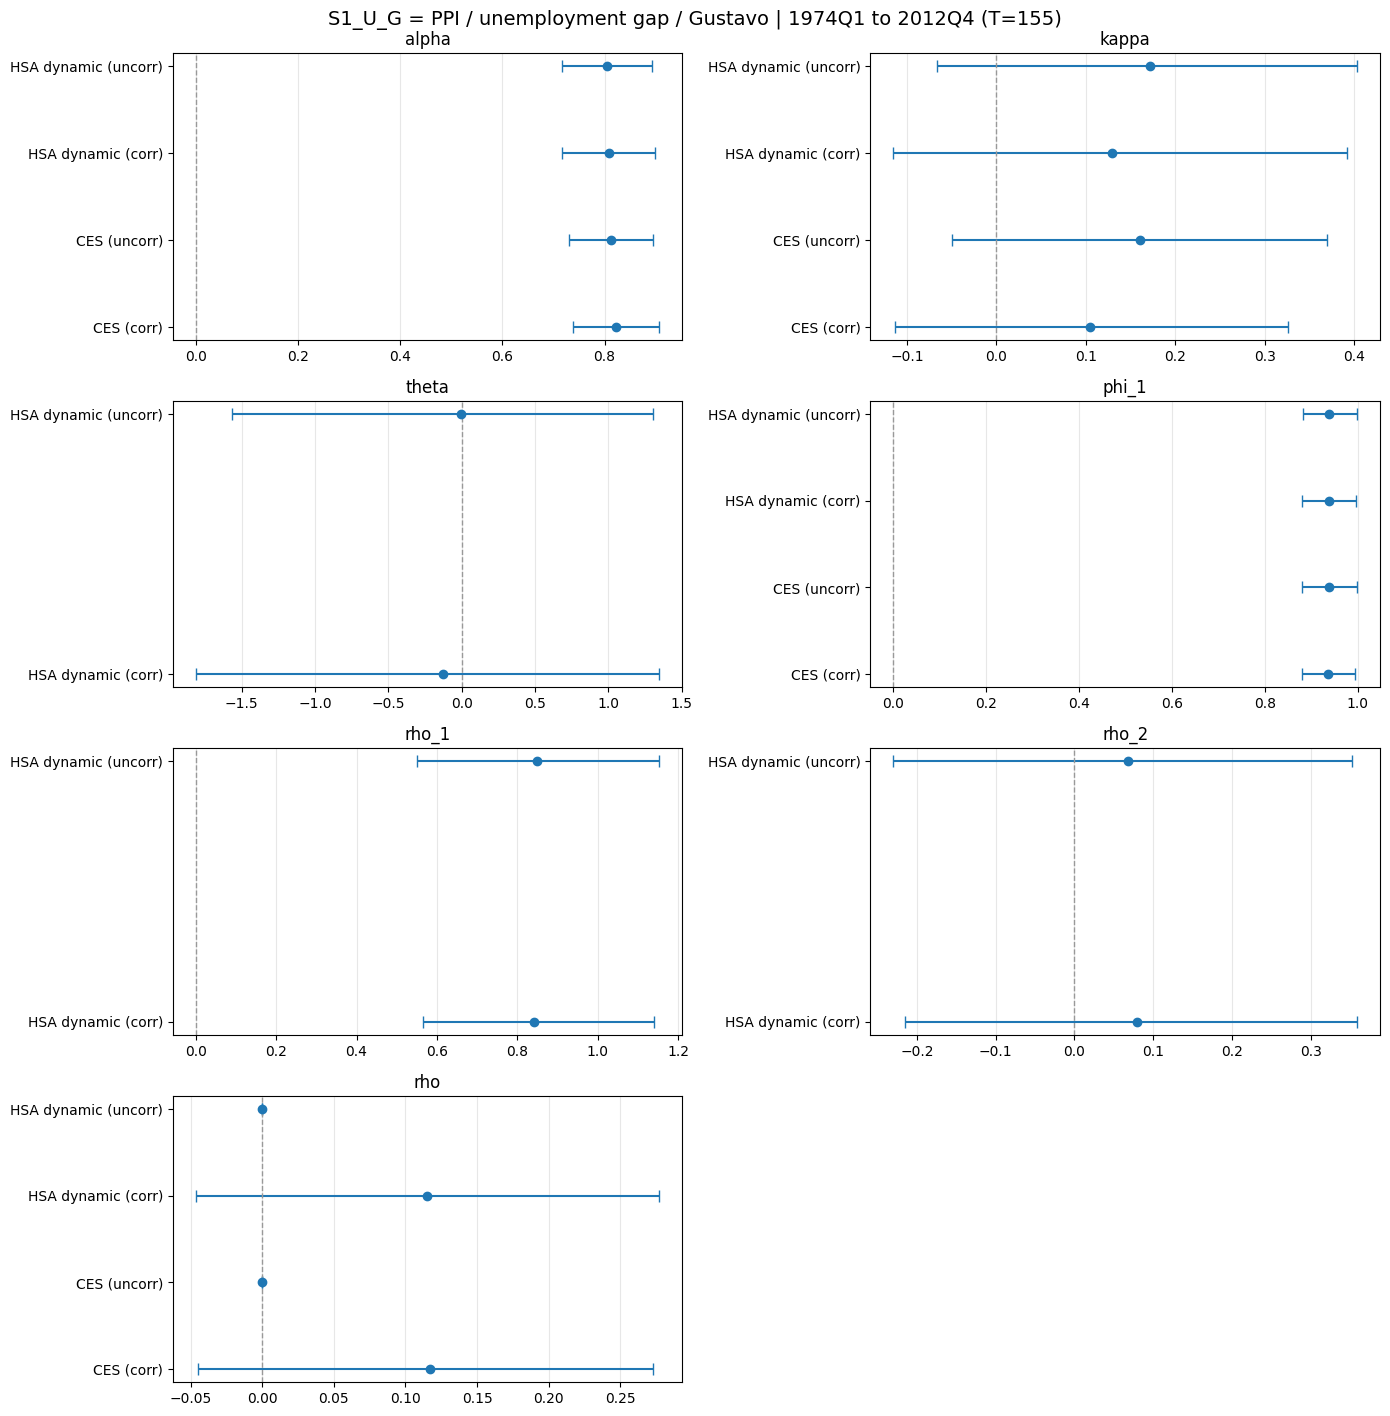

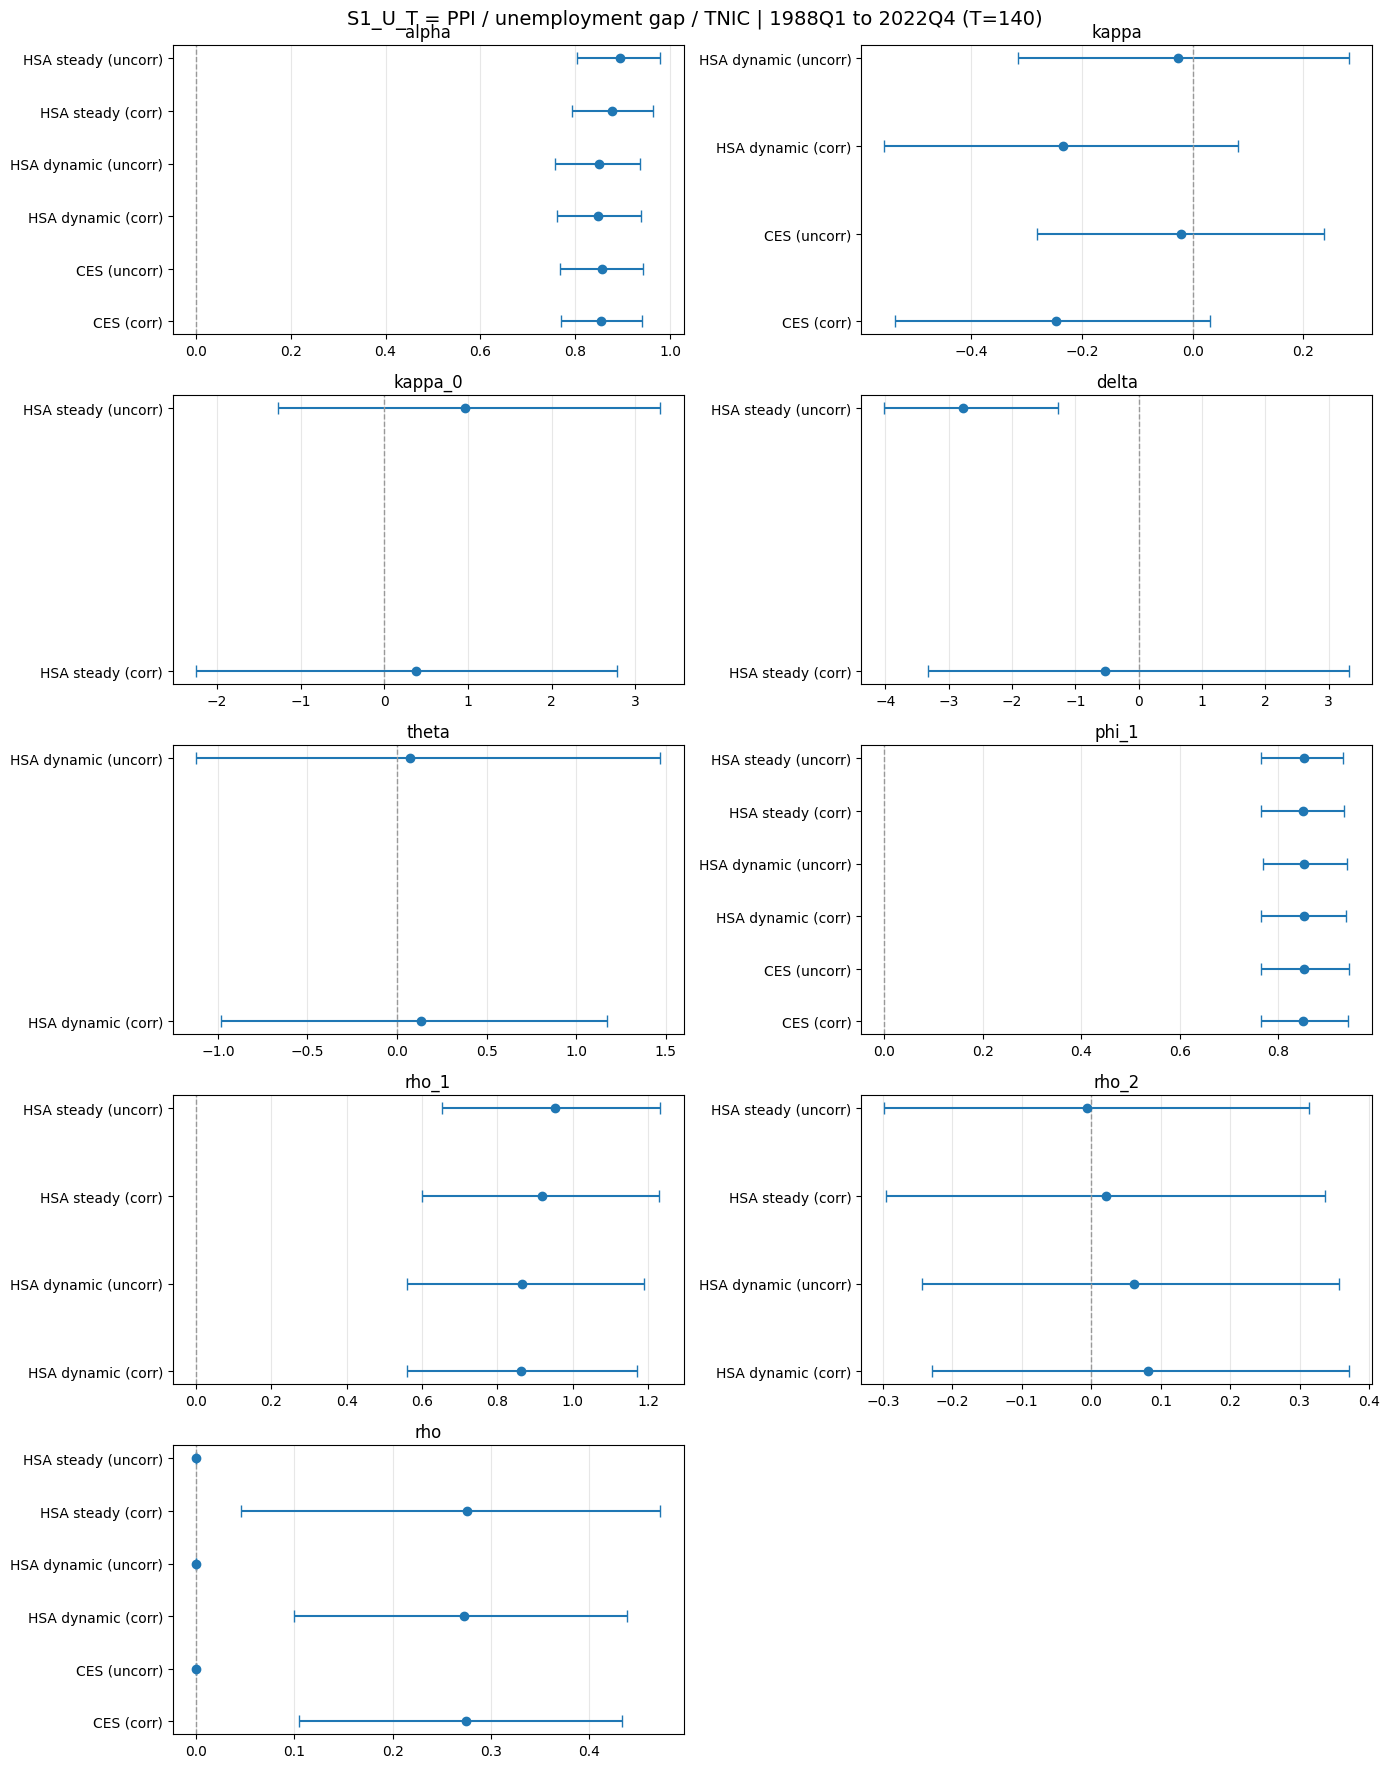

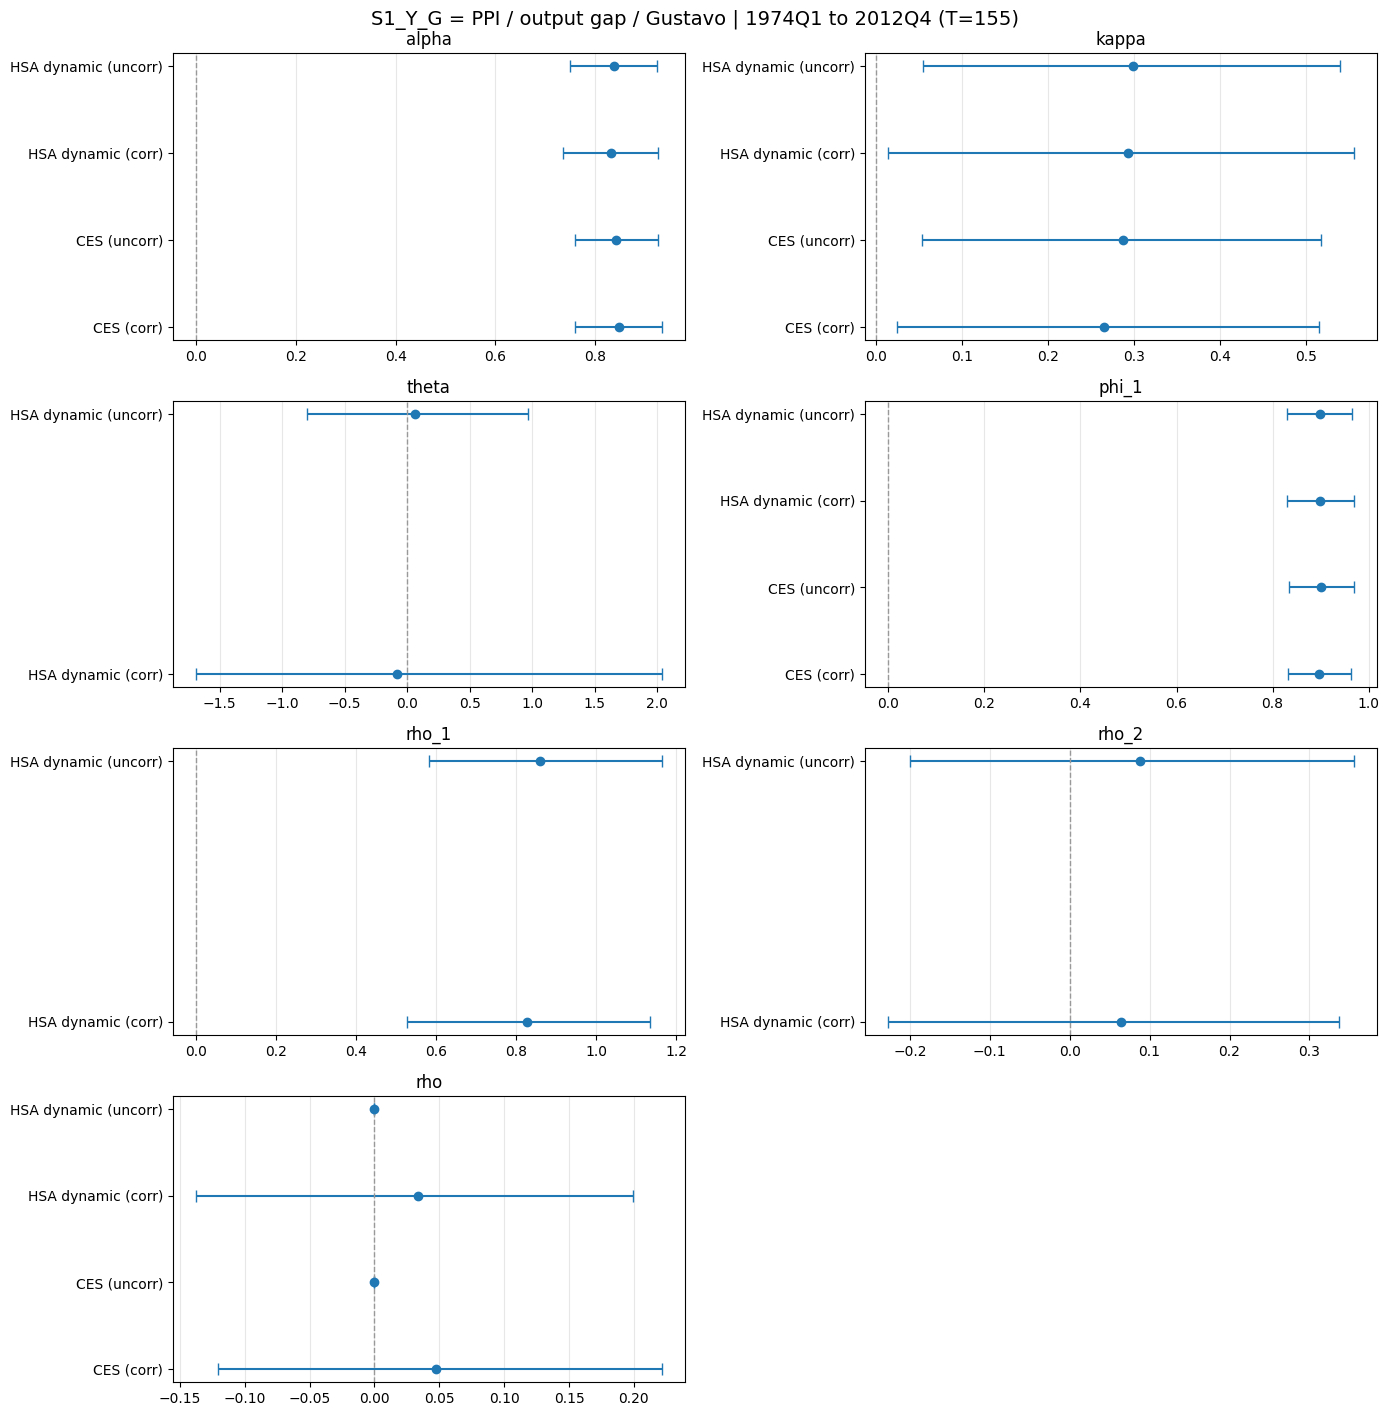

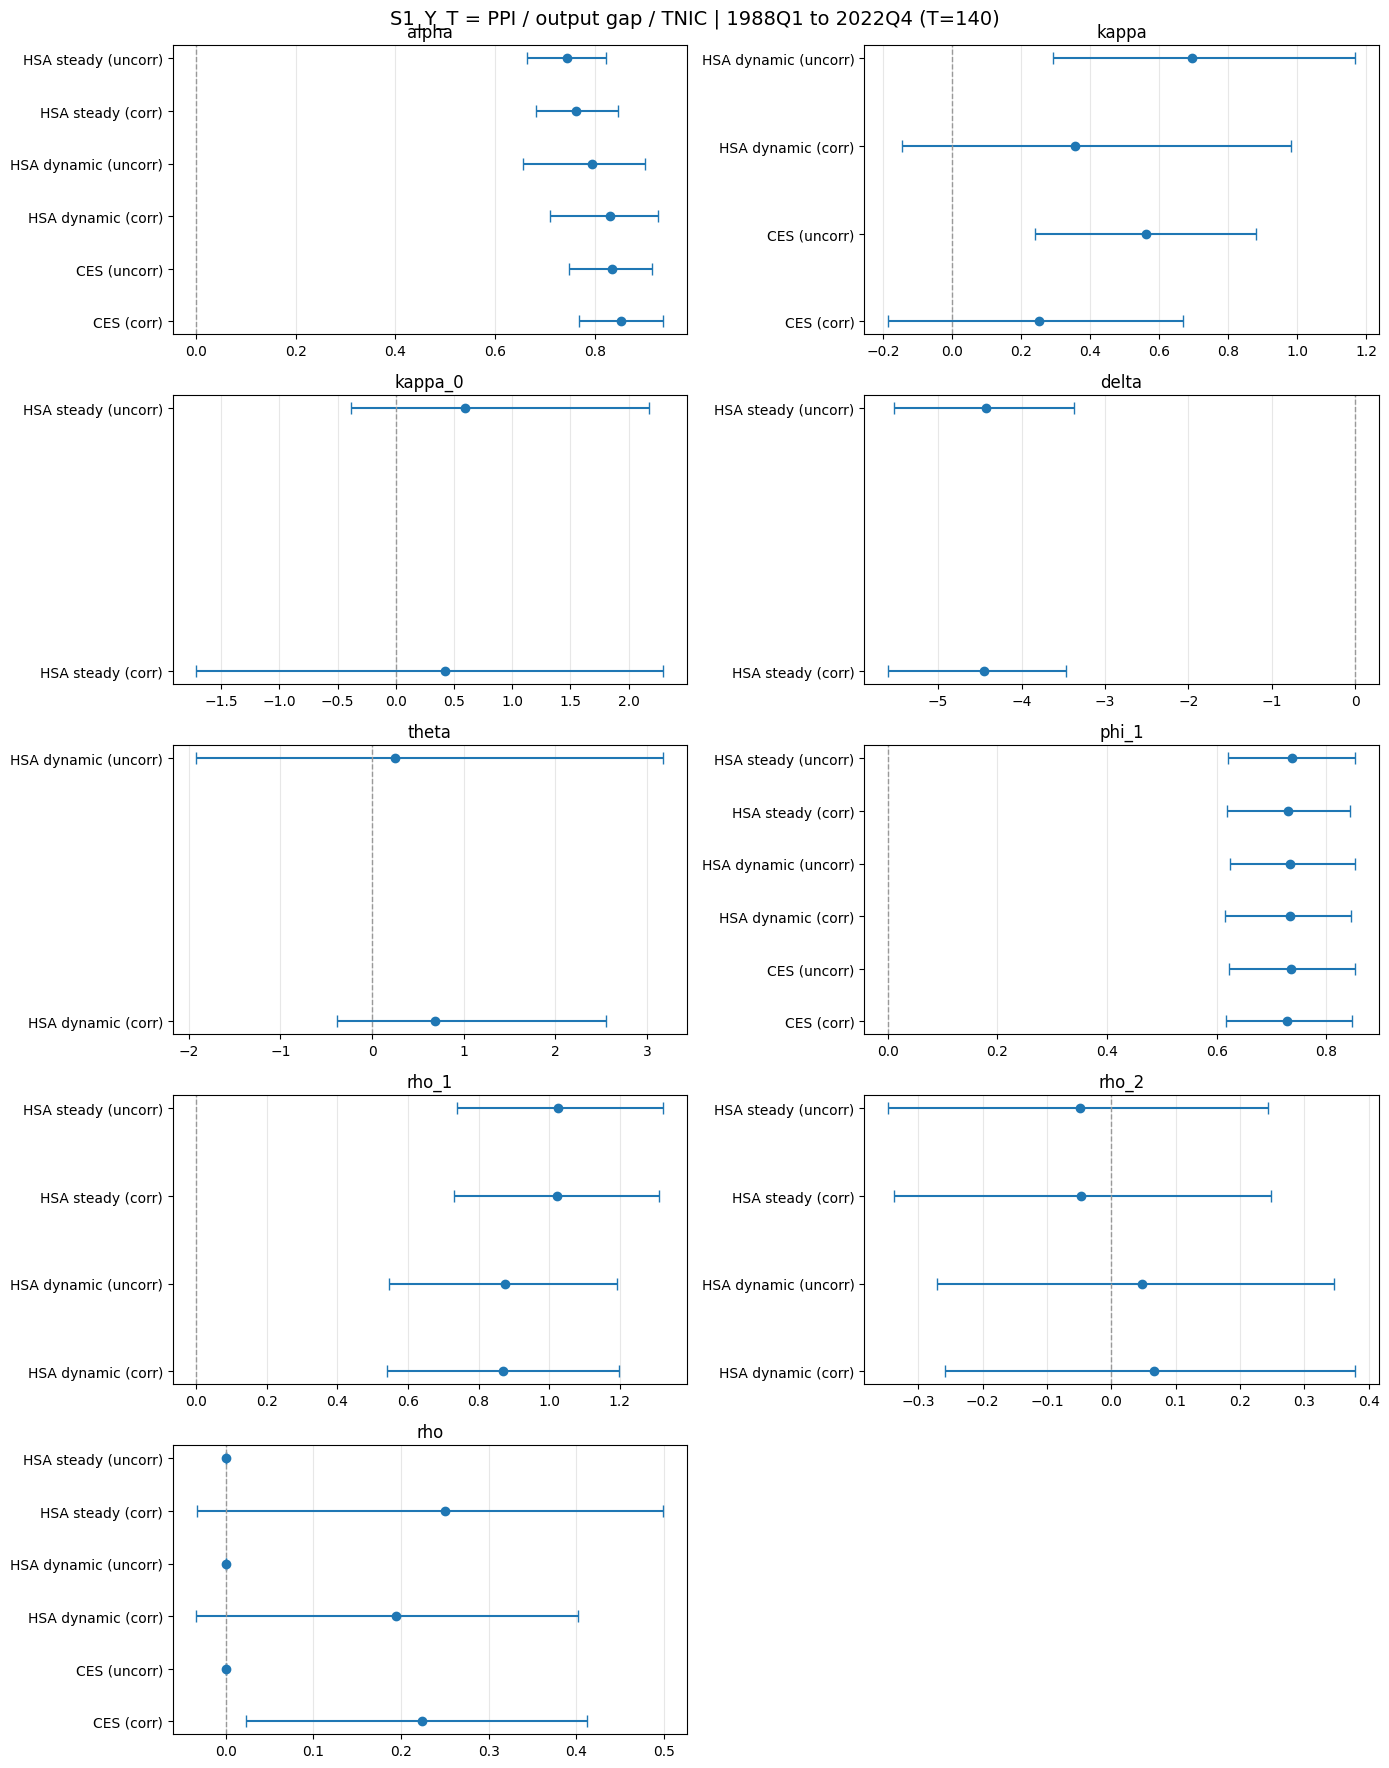

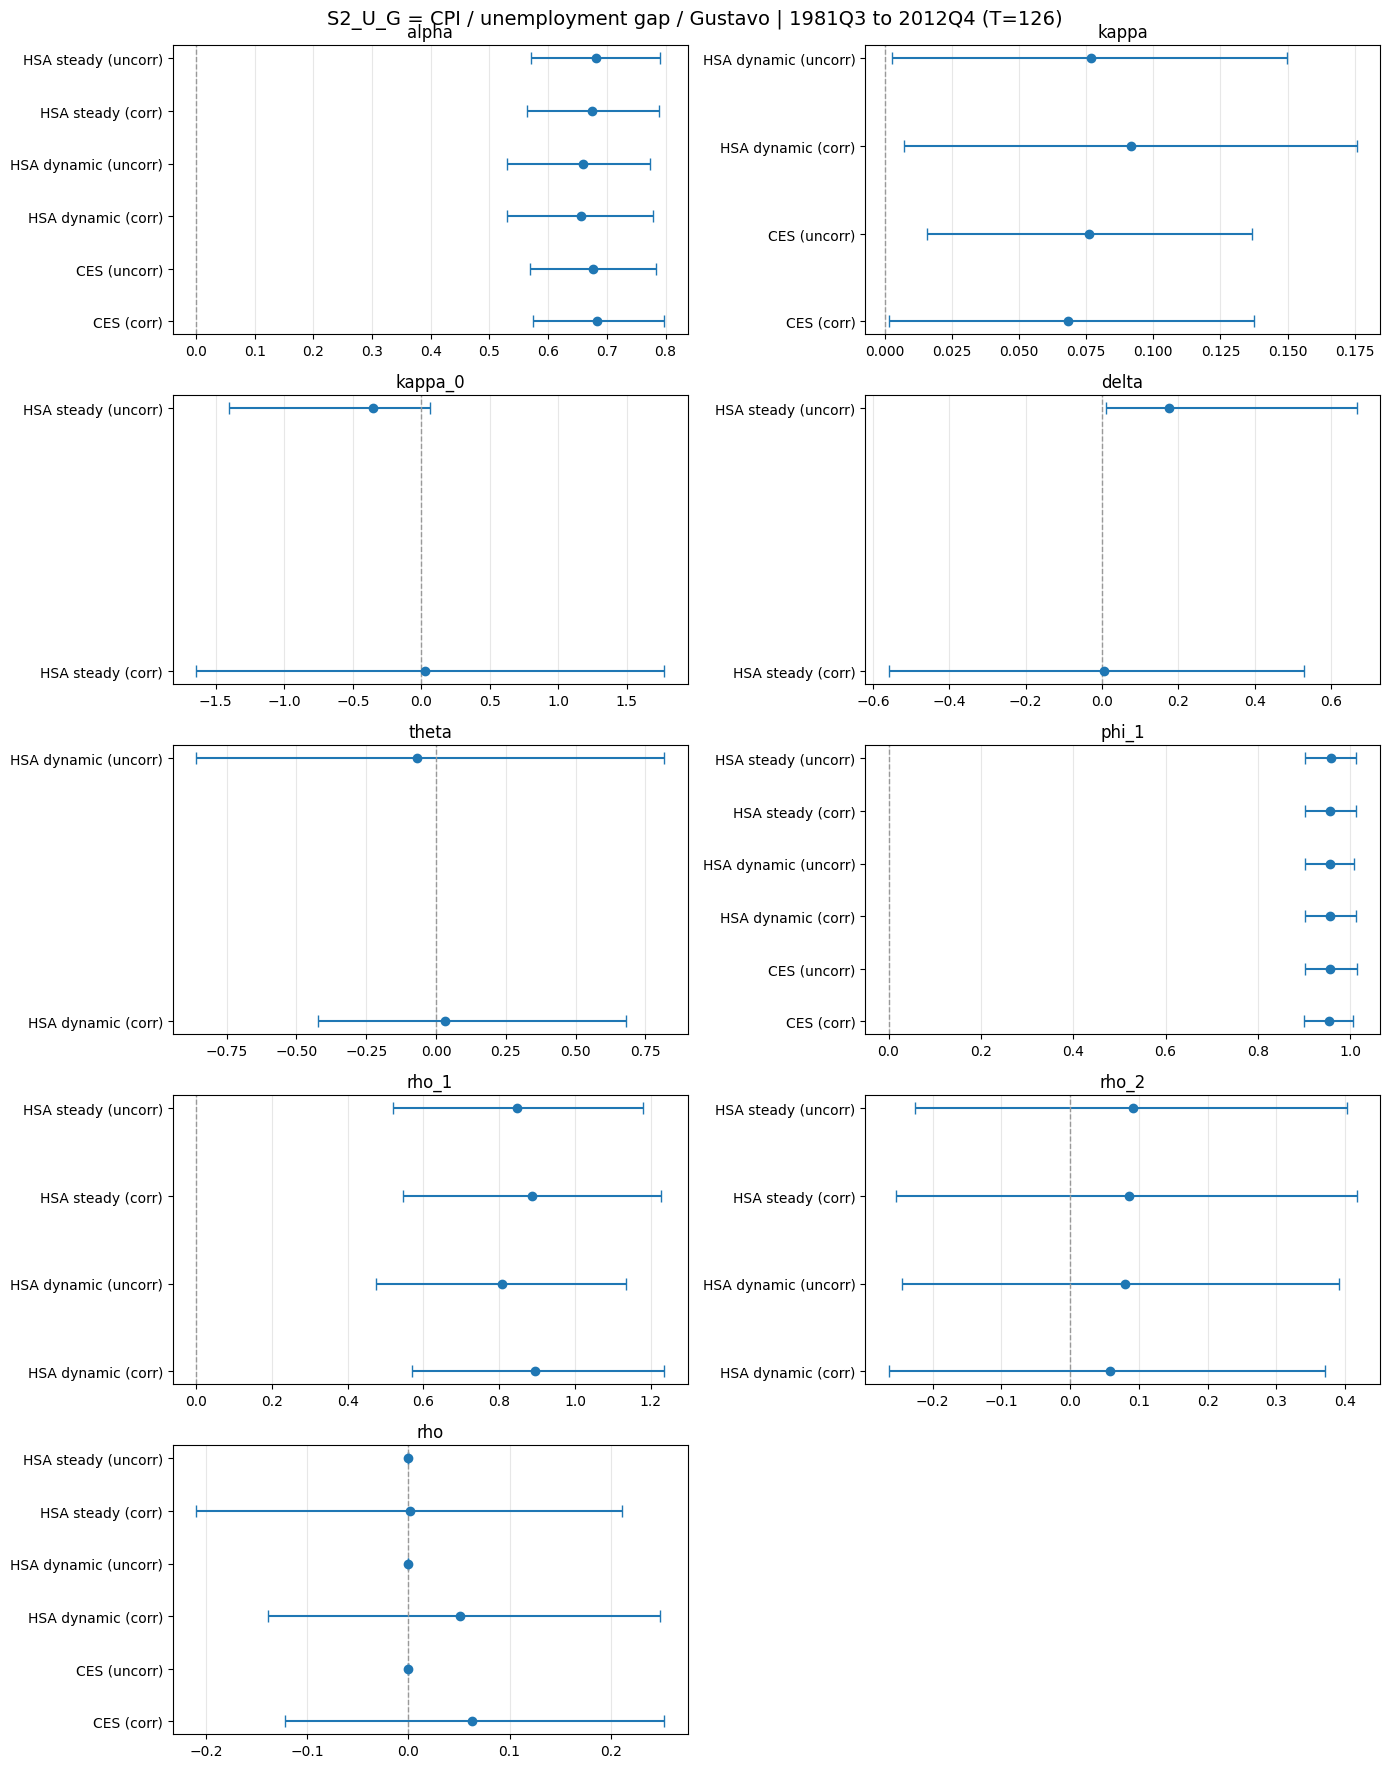

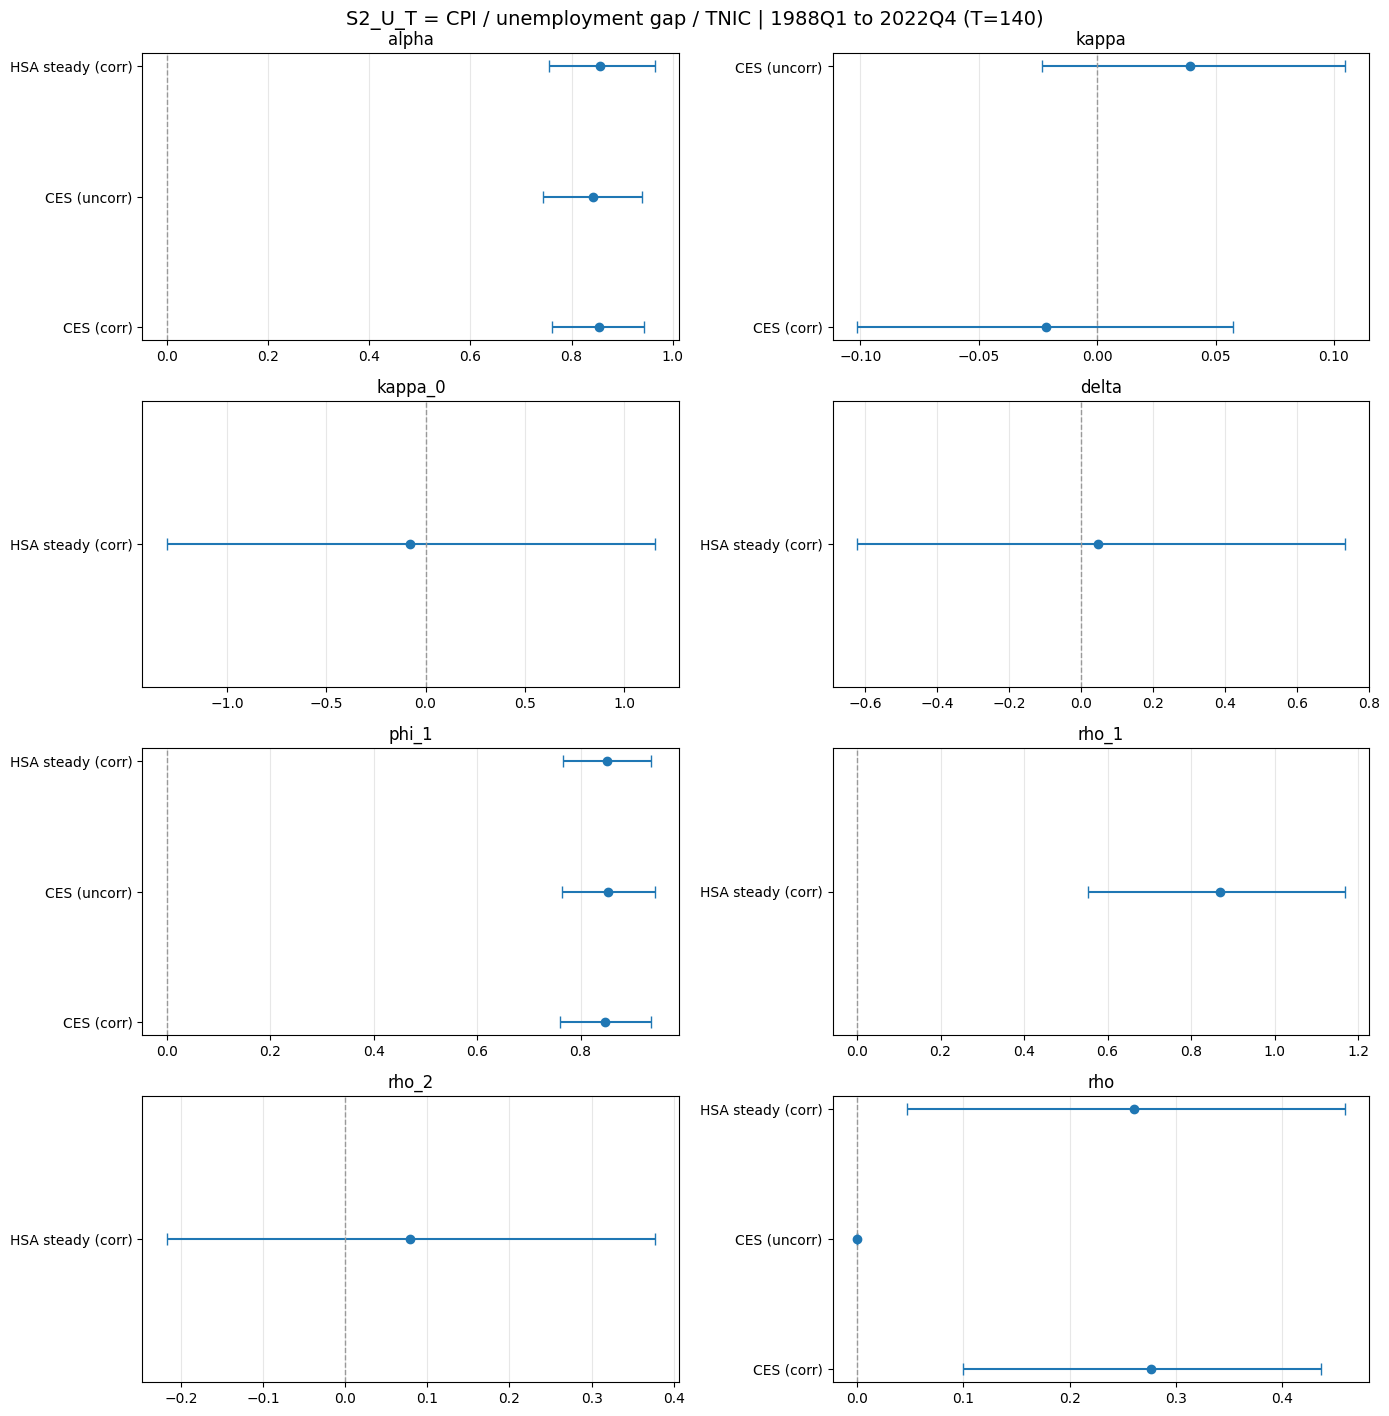

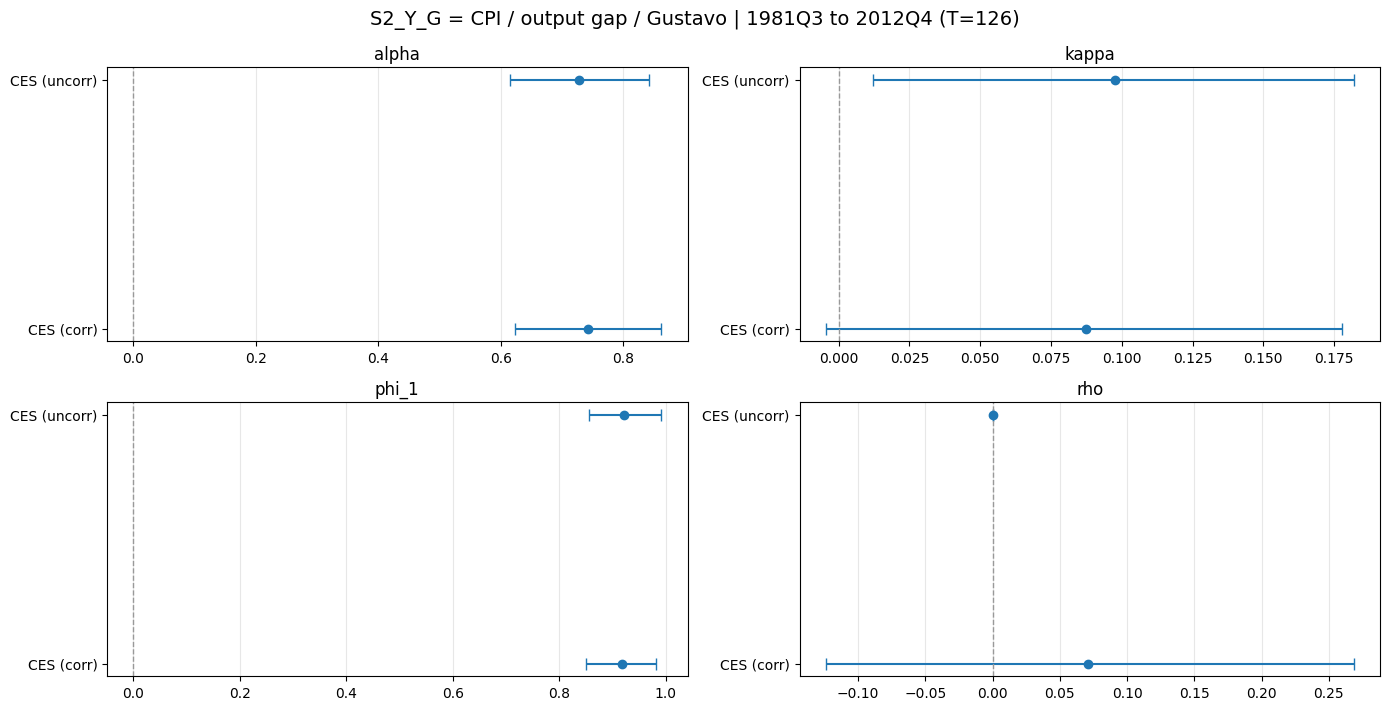

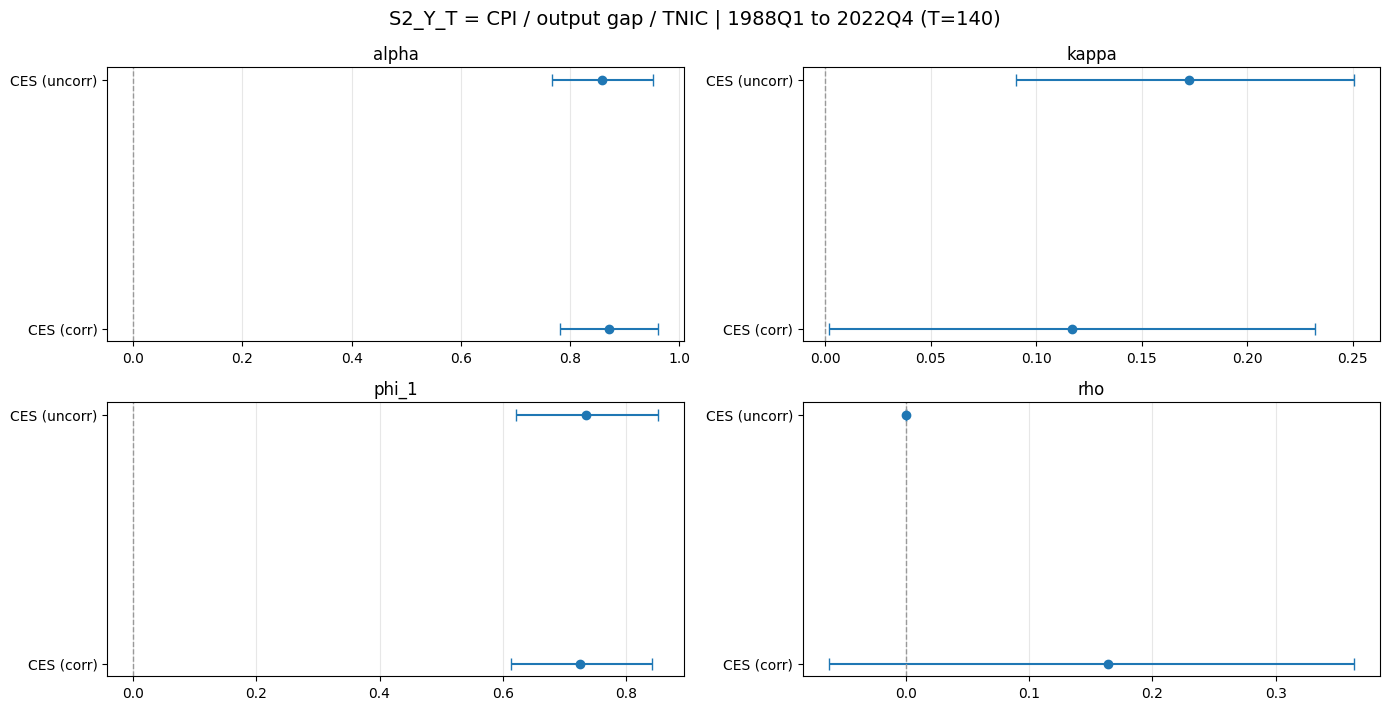

In [15]:
def plot_model_coefficients(summary, model_index, base_model: str):
    subset = summary.loc[summary["base_model"] == base_model].copy()
    if subset.empty:
        return

    plot_params = [p for p in COEFFICIENT_ORDER if p in subset["parameter"].astype(str).tolist()]
    n_params = len(plot_params)
    n_cols = 2
    n_rows = int(np.ceil(n_params / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.6 * n_rows), squeeze=False)
    axes = axes.ravel()

    subset = subset.sort_values(["parameter", "family", "corr"])

    for ax, param in zip(axes, plot_params):
        panel = subset.loc[subset["parameter"].astype(str) == param].copy()
        panel = panel.sort_values(["family", "corr"])
        y = np.arange(len(panel))
        x = panel["mean"].to_numpy()
        xerr = np.vstack([
            x - panel["ci_2.5"].to_numpy(),
            panel["ci_97.5"].to_numpy() - x,
        ])

        ax.errorbar(x, y, xerr=xerr, fmt="o", capsize=4)
        ax.axvline(0.0, color="0.6", linestyle="--", linewidth=1)
        ax.set_yticks(y)
        ax.set_yticklabels(panel["spec_label"])
        ax.set_title(param)
        ax.grid(axis="x", alpha=0.3)

    for ax in axes[n_params:]:
        ax.axis("off")

    header = (
        model_index.loc[model_index["base_model"] == base_model, ["model_title", "sample_period", "sample_size"]]
        .drop_duplicates()
        .iloc[0]
    )
    fig.suptitle(
        f"{header['model_title']} | {header['sample_period']} (T={header['sample_size']})",
        fontsize=14,
    )
    fig.tight_layout()
    plt.show()


for base_model in model_index["base_model"].drop_duplicates().tolist():
    plot_model_coefficients(coeff_summary, model_index, base_model)


S1_U_T


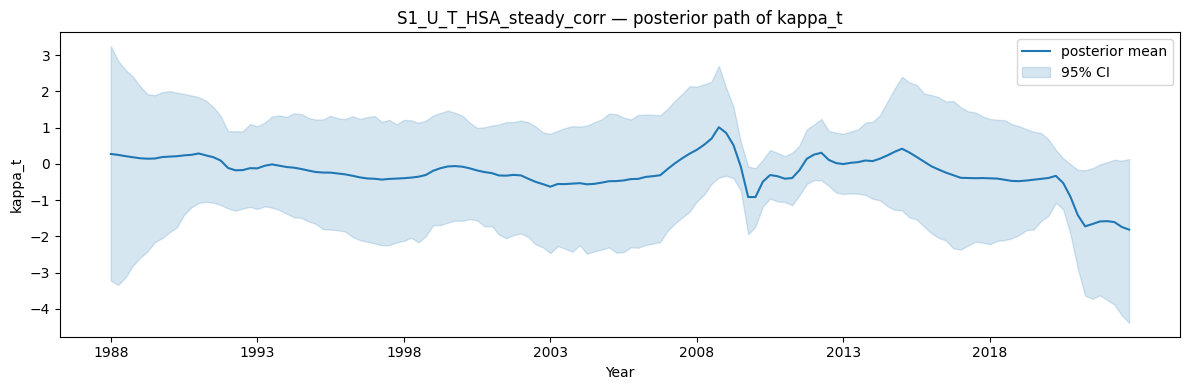

S1_Y_T


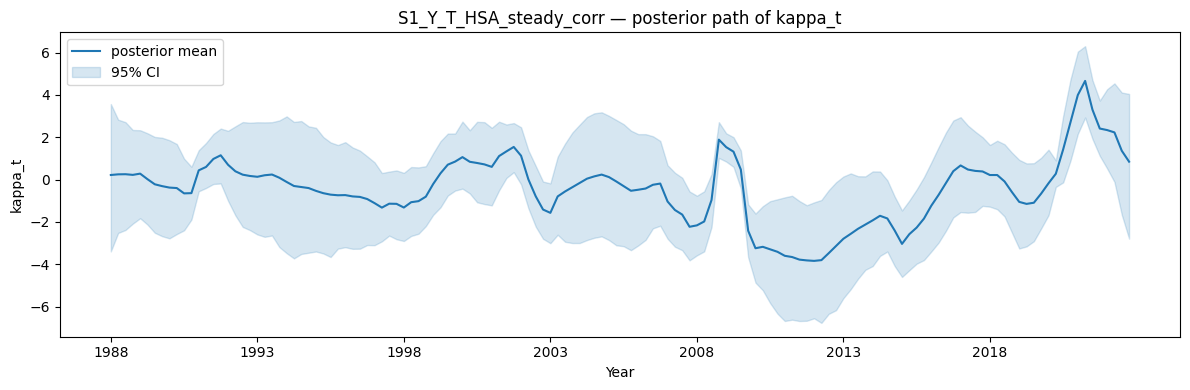

S2_U_G


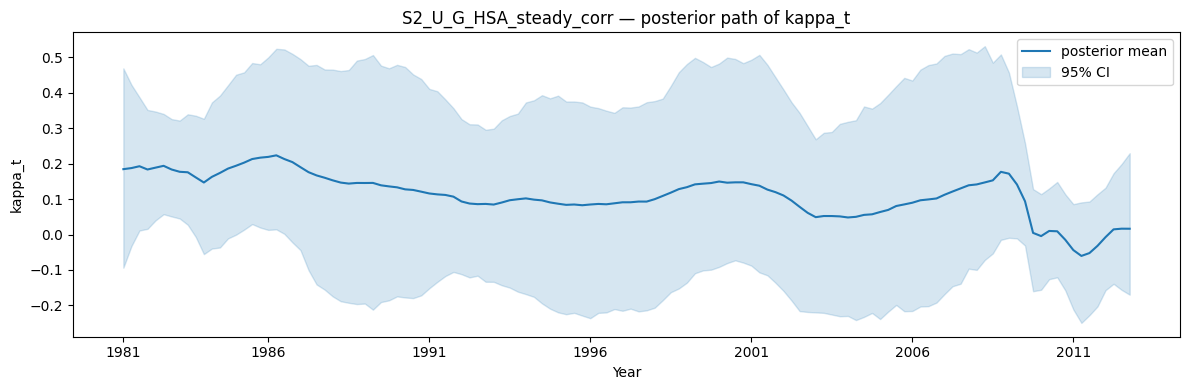

S2_U_T


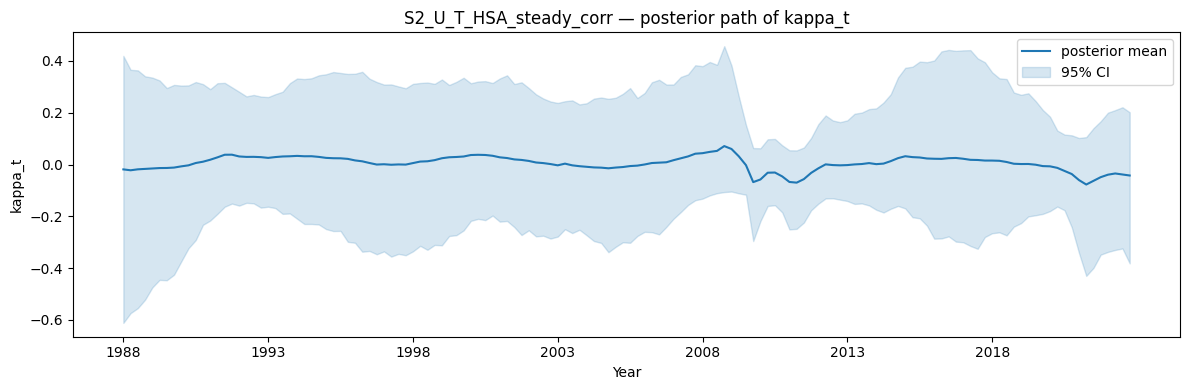

In [16]:
def show_hsa_steady_kappa_t_time_series(base_model: str, corr: str = "corr", credible: float = 0.95):
    saved_name = f"{base_model}_HSA_steady_{corr}"
    if saved_name not in idata_map:
        raise KeyError(f"{saved_name} not found in idata_map")
    ds = idata_map[saved_name]
    if "kappa_t" not in ds:
        raise KeyError(f"kappa_t not found in posterior for {saved_name}")

    kappa_t = np.asarray(ds["kappa_t"], dtype=float)
    if kappa_t.ndim == 3:
        kappa_t = kappa_t.reshape(-1, kappa_t.shape[-1])
    elif kappa_t.ndim != 2:
        raise ValueError(f"Unexpected kappa_t shape: {kappa_t.shape}")

    if not np.any(np.isfinite(kappa_t)):
        raise ValueError(f"No finite kappa_t draws found for {saved_name}")

    n_time = kappa_t.shape[1]
    sample_start = model_index.loc[model_index["saved_name"] == saved_name, "sample_start"].iloc[0]
    time_index = np.arange(n_time)
    time_dates = pd.period_range(start=sample_start, periods=n_time, freq="Q").to_timestamp(how="end")
    year_starts = {}
    for i, ts in enumerate(time_dates):
        year_starts.setdefault(int(ts.year), i)
    tick_years = list(year_starts)
    if len(tick_years) > 8:
        tick_years = tick_years[::5]
    tick_positions = [year_starts[year] for year in tick_years]
    tick_labels = [str(year) for year in tick_years]
    mean_path = np.nanmean(kappa_t, axis=0)
    lower_path = np.nanquantile(kappa_t, (1 - credible) / 2, axis=0)
    upper_path = np.nanquantile(kappa_t, 1 - (1 - credible) / 2, axis=0)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(time_index, mean_path, color="C0", label="posterior mean")
    ax.fill_between(time_index, lower_path, upper_path, color="C0", alpha=0.18, label=f"{credible*100:.0f}% CI")
    ax.set_title(f"{saved_name} — posterior path of kappa_t")
    ax.set_xlabel("Year")
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_ylabel("kappa_t")
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()
    
for base_model in model_index.loc[model_index["family"] == "HSA steady", "base_model"].drop_duplicates().tolist():
    print(base_model)
    show_hsa_steady_kappa_t_time_series(base_model, corr="corr", credible=0.95)